#CLARITY SemEval-2026 Task 6
GROUP 39: Bahar Abit, Hüseyin Eren Yıldız, İpek Uzun, Neşenaz Yalçın, Sait Kaçmaz
#


This notebook trains and evaluates multiple baselines and transformer models for 3-way classification (Ambivalent / Clear Non-Reply / Clear Reply) on the provided train/validation split.

What’s inside:

*   Baselines: TF-IDF + linear models, XGBoost (TF-IDF)
*   Embedding baseline: FastText (mean sentence vectors) + XGBoost
*   Transformers: DeBERTa variants (fine-tuning with class-weighted loss)
* Evaluation (consistent across all models)



All models are evaluated with the same pipeline (run_full_eval):

* macro Precision/Recall/F1 + classification report

* confusion matrix + One-vs-Rest PR curves

* error analysis files (including Ambivalent-focused CSVs) saved under artifacts/

Reproducibility:

A fixed seed is used where applicable, and label IDs follow the global LABELS/label2id mapping to keep results comparable across models.

In [ ]:
# ALL IMPORTS ARE HERE FOR NOTEBOOK CLARITY
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.model_selection import train_test_split
import json
from pathlib import Path

# Global Random Seed for Reproducibility
SEED = 42
np.random.seed(SEED)

from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,

)


from sklearn.preprocessing import label_binarize


# Core ML imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# Utilities
import time
import joblib
import warnings
warnings.filterwarnings('ignore')


#XGBoost Baseline — Setup
#Installs XGBoost, imports required libraries/metrics
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)



import torch.nn.functional as F




from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)




In [ ]:
# Load Datasets
splits = {
    "train": "data/train-00000-of-00001.parquet",
    "test":  "data/test-00000-of-00001.parquet",
}

train_df = pd.read_parquet("hf://datasets/ailsntua/QEvasion/" + splits["train"])
test_df  = pd.read_parquet("hf://datasets/ailsntua/QEvasion/" + splits["test"])

print(train_df.shape, test_df.shape)
print(train_df.columns.tolist())

# Inspect Label Distribution
print(train_df["clarity_label"].value_counts(dropna=False))
print(train_df["clarity_label"].unique())

(3448, 20) (308, 20)
['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label']
clarity_label
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64
['Clear Reply' 'Ambivalent' 'Clear Non-Reply']


In [ ]:
USE_COLS = [
    "question",
    "interview_answer",
    "clarity_label",
    "multiple_questions",
    "affirmative_questions",
    "inaudible",
]

# Filter Columns
USE_COLS = [c for c in USE_COLS if c in train_df.columns]

train_df = train_df[USE_COLS].copy()
test_df  = test_df[USE_COLS].copy()

# Drop Rows with Missing Core Fields
train_df = train_df.dropna(subset=["question", "interview_answer", "clarity_label"]).reset_index(drop=True)

test_df["question"] = test_df["question"].fillna("")
test_df["interview_answer"] = test_df["interview_answer"].fillna("")

In [ ]:
# Text Cleaning Function
def clean_text(x: str) -> str:
    if not isinstance(x, str):
        return ""
    x = unicodedata.normalize("NFKC", x)
    x = x.strip()
    x = re.sub(r"\s+", " ", x)
    return x

# Apply Cleaning
for df in (train_df, test_df):
    df["question_clean"] = df["question"].apply(clean_text)
    df["answer_clean"]   = df["interview_answer"].apply(clean_text)

    # Combined Input Text
    df["text"] = "Question: " + df["question_clean"] + "\nAnswer: " + df["answer_clean"]

In [ ]:
def word_len(s: str) -> int:
    return 0 if not isinstance(s, str) else len(s.split())

for df in (train_df, test_df):
    df["q_len"] = df["question_clean"].apply(word_len)
    df["a_len"] = df["answer_clean"].apply(word_len)
    df["t_len"] = df["text"].apply(word_len)

train_df[["q_len", "a_len", "t_len"]].describe()


,q_len,a_len,t_len
count,3448.000000,3448.000000,3448.000000
mean,14.462007,293.572216,310.034223
std,8.833190,301.541101,303.761579
min,1.000000,1.000000,4.000000
25%,8.000000,56.000000,70.000000
50%,12.000000,207.000000,224.000000
75%,19.000000,440.000000,459.000000
max,80.000000,2117.000000,2142.000000


In [ ]:
label_counts = train_df["clarity_label"].value_counts()
label_perc = train_df["clarity_label"].value_counts(normalize=True).mul(100).round(2)

label_table = pd.DataFrame({"count": label_counts, "percent": label_perc})
label_table

,count,percent
clarity_label,,
Ambivalent,2040,59.16
Clear Reply,1052,30.51
Clear Non-Reply,356,10.32


In [ ]:
length_summary = train_df.groupby("clarity_label")[["q_len", "a_len", "t_len"]].describe()
# quick readable view: median + mean + max
train_df.groupby("clarity_label")[["q_len","a_len","t_len"]].agg(["mean","median","max"]).round(2)

q_len              a_len                t_len             
                  mean median max    mean median   max    mean median   max
clarity_label                                                              
Ambivalent       15.30   14.0  80  331.86  243.5  2117  349.16  262.0  2142
Clear Non-Reply  12.63   11.0  55  137.81   39.5  1407  152.44   52.5  1420
Clear Reply      13.45   12.0  62  272.04  194.0  1592  287.50  210.5  1620

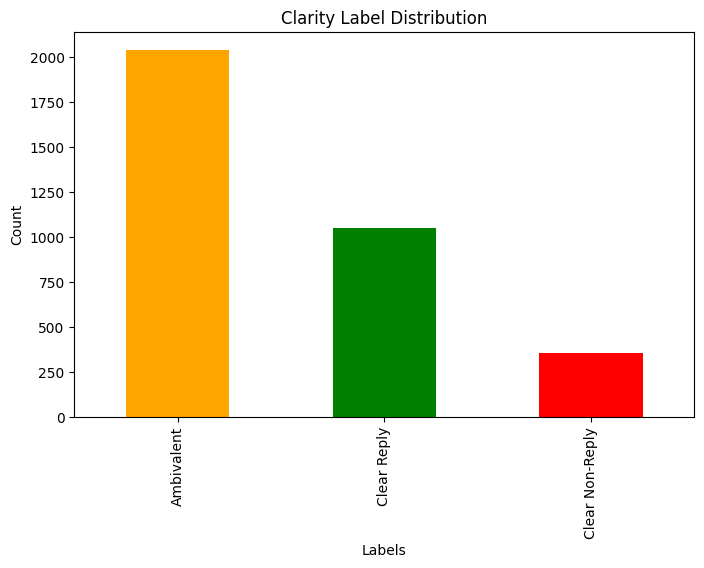

In [ ]:

# bar plot counts
plt.figure(figsize=(8,5))
label_counts.plot(kind='bar', color=['orange', 'green', 'red'])
plt.title('Clarity Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()

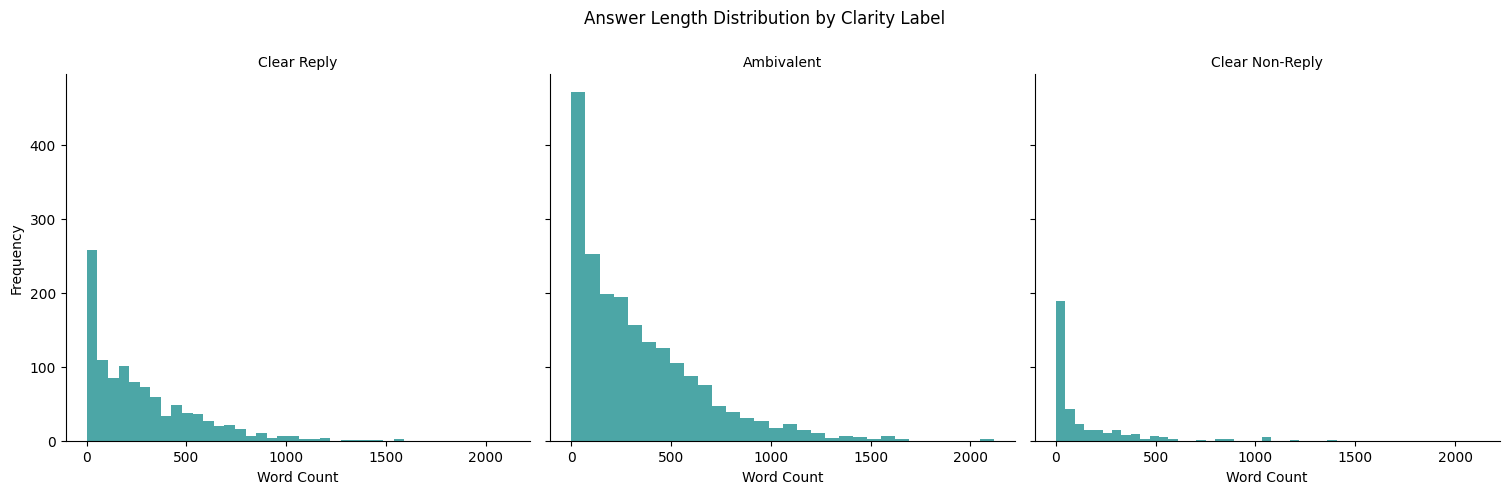

In [ ]:
#plot answer lenght by label

g = sns.FacetGrid(train_df, col="clarity_label", height=5, aspect=1)
g.map(plt.hist, "a_len", bins=30, color="teal", alpha=0.7)

g.set_axis_labels("Word Count", "Frequency")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Answer Length Distribution by Clarity Label')
plt.show()

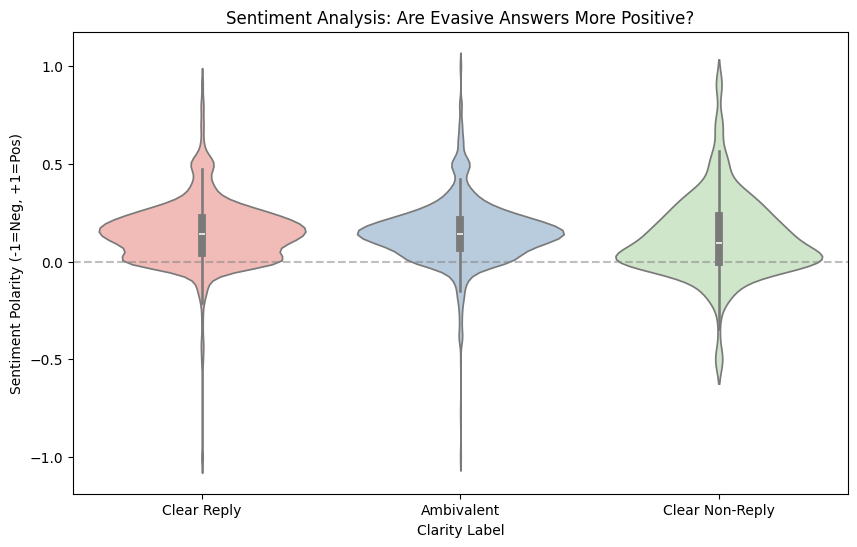

In [ ]:


# calculate sentiment polarity (-1 to +1)
# -1 is very negative, +1 is very positive
train_df['sentiment'] = train_df['interview_answer'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='clarity_label', y='sentiment', data=train_df, palette='Pastel1')
plt.title('Sentiment Analysis: Are Evasive Answers More Positive?')
plt.xlabel('Clarity Label')
plt.ylabel('Sentiment Polarity (-1=Neg, +1=Pos)')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5) # add a line at neutral
plt.show()

In [ ]:
# Stratified Train-Validation Split 85% train - 15% validation
train_split_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["clarity_label"]
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train split:", train_split_df.shape)
print("Val:", val_df.shape)

print("Train label %:\n", train_split_df["clarity_label"].value_counts(normalize=True).round(3))
print("Val label %:\n", val_df["clarity_label"].value_counts(normalize=True).round(3))

Train split: (2930, 13)
Val: (518, 13)
Train label %:
 clarity_label
Ambivalent         0.592
Clear Reply        0.305
Clear Non-Reply    0.103
Name: proportion, dtype: float64
Val label %:
 clarity_label
Ambivalent         0.591
Clear Reply        0.305
Clear Non-Reply    0.104
Name: proportion, dtype: float64


In [ ]:
# Class Weight Calculation

# Create Stable Label Mapping
LABELS = sorted(train_split_df["clarity_label"].unique().tolist())
label2id = {l:i for i,l in enumerate(LABELS)}
id2label = {i:l for l,i in label2id.items()}

# Add Numeric Labels
for df in (train_split_df, val_df, test_df):
    if "clarity_label" in df.columns:
        df["label"] = df["clarity_label"].map(label2id)

# Compute Weights (Train Set Only)
counts = train_split_df["clarity_label"].value_counts().reindex(LABELS).values
num_classes = len(LABELS)
total = counts.sum()

class_weights = (total / (num_classes * counts)).astype(np.float32)

print("LABELS order:", LABELS)
print("counts:", counts)
print("class_weights:", class_weights)

LABELS order: ['Ambivalent', 'Clear Non-Reply', 'Clear Reply']
counts: [1734  302  894]
class_weights: [0.5632449 3.2339957 1.0924683]


#Unified Evaluation + Error Analysis Helpers

This cell standardizes evaluation across ALL models in this notebook.


*   Outputs: macro-F1 / macro-precision / macro-recall + per-class, confusion matrix PNG, PR curves PNG, and Ambivalent-focused error CSV for reviewer.





In [ ]:
ART = Path("artifacts")
ART.mkdir(exist_ok=True)

# Core Evaluation Metrics
def _eval_core(y_true, y_pred, labels):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_c, r_c, f1_c, sup_c = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=list(range(len(labels))), zero_division=0
    )
    return {
        "macro_precision": float(p),
        "macro_recall": float(r),
        "macro_f1": float(f1),
        "per_class": {
            labels[i]: {
                "precision": float(p_c[i]),
                "recall": float(r_c[i]),
                "f1": float(f1_c[i]),
                "support": int(sup_c[i]),
            } for i in range(len(labels))
        }
    }

# Confusion Matrix Visualization
def _save_confusion(y_true, y_pred, labels, tag):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(7,6))
    disp.plot(ax=ax, values_format="d", cmap=plt.cm.Blues)
    ax.set_title(f"Confusion Matrix ({tag})")
    plt.tight_layout()
    out = ART / f"confusion_{tag}.png"
    plt.savefig(out, dpi=200)
    plt.show()
    return str(out)

# Precision-Recall Curves
def _save_pr_curves(y_true, y_score, labels, tag):
    y_true_bin = label_binarize(y_true, classes=list(range(len(labels))))
    fig, ax = plt.subplots(figsize=(7,6))
    for c in range(len(labels)):
        prec, rec, _ = precision_recall_curve(y_true_bin[:, c], y_score[:, c])
        ap = average_precision_score(y_true_bin[:, c], y_score[:, c])
        ax.plot(rec, prec, label=f"{labels[c]} (AP={ap:.3f})")
    ax.set_title(f"PR Curves OvR ({tag})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    plt.tight_layout()
    out = ART / f"pr_curves_{tag}.png"
    plt.savefig(out, dpi=200)
    plt.show()
    return str(out)

# Error Analysis DataFrame
def _build_error_df(base_df, y_true, y_pred, y_score, labels):
    base_df = base_df.reset_index(drop=True).copy()
    base_df["true_id"] = y_true
    base_df["pred_id"] = y_pred
    base_df["true_label"] = [labels[i] for i in y_true]
    base_df["pred_label"] = [labels[i] for i in y_pred]
    base_df["confidence"] = np.max(y_score, axis=1)
    base_df["is_error"] = base_df["true_id"] != base_df["pred_id"]
    return base_df

# Ambivalent Class Report
def _ambivalent_report(err_df, labels, tag, k=12):
    amb = "Ambivalent Reply" if "Ambivalent Reply" in labels else None
    if amb is None:
        cand = [l for l in labels if ("Ambiv" in l) or ("Ambig" in l)]
        amb = cand[0] if cand else labels[0]

    true_amb = err_df[err_df["true_label"] == amb]
    amb_err  = true_amb[true_amb["is_error"]]

    summary = {
        "amb_label": amb,
        "true_amb_count": int(len(true_amb)),
        "amb_error_count": int(len(amb_err)),
        "amb_misclassified_as": amb_err["pred_label"].value_counts().to_dict()
    }

    low_conf  = amb_err.sort_values("confidence").head(k).assign(bucket="low_conf")
    high_conf = amb_err.sort_values("confidence", ascending=False).head(k).assign(bucket="high_conf")
    ex = pd.concat([low_conf, high_conf], axis=0)

    keep = [c for c in [
        "bucket","true_label","pred_label","confidence",
        "question","interview_answer","text",
        "multiple_questions","affirmative_questions","inaudible"
    ] if c in ex.columns]

    ex_path = ART / f"ambivalent_examples_{tag}.csv"
    ex[keep].reset_index(drop=True).to_csv(ex_path, index=False)

    full_path = ART / f"errors_full_{tag}.csv"
    err_df.to_csv(full_path, index=False)

    return summary, str(ex_path), str(full_path)

# Unified Evaluation Runner
def run_full_eval(tag, y_true, y_pred, y_score, labels, base_df, make_plots=True):
    metrics = _eval_core(y_true, y_pred, labels)
    metrics["tag"] = tag

    if make_plots:
        metrics["confusion_path"] = _save_confusion(y_true, y_pred, labels, tag)
        metrics["pr_path"] = _save_pr_curves(y_true, y_score, labels, tag)
    else:
        metrics["confusion_path"] = None
        metrics["pr_path"] = None

    err_df = _build_error_df(base_df, y_true, y_pred, y_score, labels)
    amb_sum, amb_csv, full_csv = _ambivalent_report(err_df, labels, tag)
    metrics["ambivalent_summary"] = amb_sum
    metrics["ambivalent_examples_csv"] = amb_csv
    metrics["errors_full_csv"] = full_csv

    out_json = ART / f"metrics_{tag}.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)
    print("Saved ->", out_json)

    return metrics

In [ ]:
# Fixing Class imbalance - Oversampling for Class Balance
max_n = train_split_df["clarity_label"].value_counts().max()

balanced_train_df = (
    train_split_df
    .groupby("clarity_label", group_keys=False)
    .apply(lambda x: x.sample(max_n, replace=True, random_state=SEED))
    .sample(frac=1.0, random_state=SEED)  # shuffle
    .reset_index(drop=True)
)

print(balanced_train_df["clarity_label"].value_counts())

clarity_label
Clear Non-Reply    1734
Ambivalent         1734
Clear Reply        1734
Name: count, dtype: int64


# TF-IDF Baseline Models

**Assigned:** Sait Kaçmaz | **Reviewers:** İpek Uzun, Neşenaz Yalçın

This section implements traditional machine learning baselines using TF-IDF features:
- **Logistic Regression** - Interpretable linear model
- **Linear SVM** - Maximum-margin classifier for high-dimensional text
- **Decision Tree** - Non-linear model with interpretable rules

We experiment with multiple n-gram configurations (unigrams, bigrams, trigrams) and use 5-fold stratified cross-validation for hyperparameter tuning.

In [ ]:
# ============================================================================
# TF-IDF BASELINE MODELS - IMPORTS AND CONFIGURATION
# ============================================================================




# Verify existing variables from previous cells
print("=" * 60)
print("TF-IDF BASELINE SETUP")
print("=" * 60)
print(f"Training samples: {len(train_split_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Labels: {LABELS}")
print(f"Random seed: {SEED}")
print(f"Class weights: {class_weights}")

TF-IDF BASELINE SETUP
Training samples: 2930
Validation samples: 518
Test samples: 308
Labels: ['Ambivalent', 'Clear Non-Reply', 'Clear Reply']
Random seed: 42
Class weights: [0.5632449 3.2339957 1.0924683]


In [ ]:
# ============================================================================
# DATA PREPARATION FOR TF-IDF
# ============================================================================

# Extract text and labels from DataFrames
# Using the combined "Question: [Q]\nAnswer: [A]" format from preprocessing
X_train = train_split_df["text"].values
y_train = train_split_df["clarity_label"].values

X_val = val_df["text"].values
y_val = val_df["clarity_label"].values

# Verify data shapes
print("Data prepared for TF-IDF models:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val.shape}")

# Show label distribution in training set
print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts())

# Sample text preview
print("\nSample training text (first 200 chars):")
print(X_train[0][:200] + "...")

Data prepared for TF-IDF models:
  X_train shape: (2930,)
  y_train shape: (2930,)
  X_val shape: (518,)
  y_val shape: (518,)

Training label distribution:
Ambivalent         1734
Clear Reply         894
Clear Non-Reply     302
Name: count, dtype: int64

Sample training text (first 200 chars):
Question: What can you do about that?
Answer: Well, I really think the stock market—of something I know a lot about—I think it took a hit maybe for two reasons. I think they look at the people that yo...


In [ ]:
# ============================================================================
# TF-IDF AND MODEL CONFIGURATIONS
# ============================================================================

# TF-IDF Configurations to test
TFIDF_CONFIGS = {
    'unigram': {
        'ngram_range': (1, 1),
        'max_features': 5000,
        'min_df': 2,
        'max_df': 0.95,
        'sublinear_tf': True,
        'lowercase': True,
    },
    'bigram': {
        'ngram_range': (1, 2),
        'max_features': 5000,
        'min_df': 2,
        'max_df': 0.95,
        'sublinear_tf': True,
        'lowercase': True,
    },
    'trigram': {
        'ngram_range': (1, 3),
        'max_features': 5000,
        'min_df': 2,
        'max_df': 0.95,
        'sublinear_tf': True,
        'lowercase': True,
    },
}

# Model configurations with hyperparameter grids
MODEL_CONFIGS = {
    'lr': {
        'name': 'Logistic Regression',
        'model_class': LogisticRegression,
        'default_params': {'max_iter': 1000, 'random_state': SEED},
        'param_grid': {
            'clf__C': [0.1, 1.0, 10.0],
            'clf__class_weight': ['balanced', None],
        }
    },
    'svm': {
        'name': 'Linear SVM',
        'model_class': LinearSVC,
        'default_params': {'max_iter': 2000, 'random_state': SEED, 'dual': True},
        'param_grid': {
            'clf__C': [0.1, 1.0, 10.0],
            'clf__class_weight': ['balanced', None],
        }
    },
    'dt': {
        'name': 'Decision Tree',
        'model_class': DecisionTreeClassifier,
        'default_params': {'random_state': SEED},
        'param_grid': {
            'clf__max_depth': [5, 10, 20],
            'clf__min_samples_split': [2, 5],
            'clf__class_weight': ['balanced', None],
        }
    },
}

print("Experiment Configuration:")
print(f"  TF-IDF configs: {list(TFIDF_CONFIGS.keys())}")
print(f"  Model types: {list(MODEL_CONFIGS.keys())}")
print(f"  Total experiments: {len(TFIDF_CONFIGS) * len(MODEL_CONFIGS)}")

# Show TF-IDF config details
print("\nTF-IDF Configuration Details:")
for name, config in TFIDF_CONFIGS.items():
    print(f"  {name}: ngram_range={config['ngram_range']}, max_features={config['max_features']}")

Experiment Configuration:
  TF-IDF configs: ['unigram', 'bigram', 'trigram']
  Model types: ['lr', 'svm', 'dt']
  Total experiments: 9

TF-IDF Configuration Details:
  unigram: ngram_range=(1, 1), max_features=5000
  bigram: ngram_range=(1, 2), max_features=5000
  trigram: ngram_range=(1, 3), max_features=5000


In [ ]:
# ============================================================================
# TRAINING AND EVALUATION FUNCTIONS
# ============================================================================

def create_pipeline(tfidf_config, model_config):
    """Create TF-IDF + Classifier pipeline."""
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_config)),
        ('clf', model_config['model_class'](**model_config['default_params']))
    ])
    return pipeline


def run_experiment(tfidf_name, tfidf_config, model_name, model_config,
                   X_train, y_train, X_val, y_val, labels):
    """
    Run a single experiment with grid search and evaluation.

    Returns:
        dict: Experiment results including metrics, predictions, and trained model
    """
    print(f"\n{'='*60}")
    print(f"Running: {model_config['name']} + {tfidf_name}")
    print(f"{'='*60}")

    # Create pipeline
    pipeline = create_pipeline(tfidf_config, model_config)

    # Setup cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    # Grid search
    start_time = time.time()
    grid_search = GridSearchCV(
        pipeline,
        model_config['param_grid'],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    grid_search.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Get best model and predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_val)

    # Calculate metrics
    val_macro_f1 = f1_score(y_val, y_pred, average='macro')
    val_precision = precision_score(y_val, y_pred, average='macro')
    val_recall = recall_score(y_val, y_pred, average='macro')

    # Per-class F1
    per_class_f1 = f1_score(y_val, y_pred, average=None, labels=labels)

    # Collect results
    result = {
        'experiment_id': f"{model_name}_{tfidf_name}",
        'model_type': model_config['name'],
        'tfidf_config': tfidf_name,
        'ngram_range': str(tfidf_config['ngram_range']),
        'max_features': tfidf_config['max_features'],
        'best_params': str(grid_search.best_params_),
        'cv_macro_f1': round(grid_search.best_score_, 4),
        'val_macro_f1': round(val_macro_f1, 4),
        'val_precision': round(val_precision, 4),
        'val_recall': round(val_recall, 4),
        'f1_ambivalent': round(per_class_f1[0], 4),
        'f1_clear_nonreply': round(per_class_f1[1], 4),
        'f1_clear_reply': round(per_class_f1[2], 4),
        'training_time_sec': round(training_time, 2),
        'best_model': best_model,
        'y_pred': y_pred,
    }

    print(f"  Best CV Macro-F1: {grid_search.best_score_:.4f}")
    print(f"  Val Macro-F1: {val_macro_f1:.4f}")
    print(f"  Best Params: {grid_search.best_params_}")
    print(f"  Training Time: {training_time:.1f}s")

    return result


print("Functions defined successfully!")
print("  - create_pipeline(): Creates TF-IDF + Classifier pipeline")
print("  - run_experiment(): Runs grid search and evaluation")

Functions defined successfully!
  - create_pipeline(): Creates TF-IDF + Classifier pipeline
  - run_experiment(): Runs grid search and evaluation


In [ ]:
# ============================================================================
# RUN ALL EXPERIMENTS
# ============================================================================

print("Starting TF-IDF baseline experiments...")
print(f"Total experiments to run: {len(TFIDF_CONFIGS) * len(MODEL_CONFIGS)}")
print("This may take a few minutes...\n")

# Store all results
all_results = []

# Run all combinations
total_start = time.time()

for tfidf_name, tfidf_config in TFIDF_CONFIGS.items():
    for model_name, model_config in MODEL_CONFIGS.items():
        result = run_experiment(
            tfidf_name, tfidf_config,
            model_name, model_config,
            X_train, y_train,
            X_val, y_val,
            labels=LABELS
        )
        all_results.append(result)

total_time = time.time() - total_start

print(f"\n{'='*60}")
print(f"COMPLETED {len(all_results)} EXPERIMENTS!")
print(f"Total time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print(f"{'='*60}")

Starting TF-IDF baseline experiments...
Total experiments to run: 9
This may take a few minutes...


Running: Logistic Regression + unigram
  Best CV Macro-F1: 0.5008
  Val Macro-F1: 0.5901
  Best Params: {'clf__C': 10.0, 'clf__class_weight': 'balanced'}
  Training Time: 13.6s

Running: Linear SVM + unigram
  Best CV Macro-F1: 0.4975
  Val Macro-F1: 0.5424
  Best Params: {'clf__C': 0.1, 'clf__class_weight': 'balanced'}
  Training Time: 5.5s

Running: Decision Tree + unigram
  Best CV Macro-F1: 0.4541
  Val Macro-F1: 0.5484
  Best Params: {'clf__class_weight': None, 'clf__max_depth': 20, 'clf__min_samples_split': 2}
  Training Time: 13.4s

Running: Logistic Regression + bigram
  Best CV Macro-F1: 0.5114
  Val Macro-F1: 0.5781
  Best Params: {'clf__C': 10.0, 'clf__class_weight': 'balanced'}
  Training Time: 22.5s

Running: Linear SVM + bigram
  Best CV Macro-F1: 0.5095
  Val Macro-F1: 0.5184
  Best Params: {'clf__C': 0.1, 'clf__class_weight': 'balanced'}
  Training Time: 12.4s

Running: 

In [ ]:
# ============================================================================
# RESULTS COMPARISON TABLE
# ============================================================================

# Create results DataFrame
results_df = pd.DataFrame(all_results)

# Select columns for display (exclude model objects and predictions)
display_cols = [
    'experiment_id', 'model_type', 'tfidf_config', 'ngram_range',
    'cv_macro_f1', 'val_macro_f1', 'val_precision', 'val_recall',
    'f1_ambivalent', 'f1_clear_nonreply', 'f1_clear_reply',
    'training_time_sec'
]

# Sort by validation macro-F1 (descending)
results_display = results_df[display_cols].sort_values('val_macro_f1', ascending=False)

# Display the results
print("\n" + "="*80)
print("TF-IDF BASELINE RESULTS - SORTED BY VALIDATION MACRO-F1")
print("="*80)

best_tfidf_f1 = results_display['val_macro_f1'].max()
print(f"Best TF-IDF model Macro-F1: {best_tfidf_f1:.4f}")

print("\n" + "-"*80)
display(results_display.reset_index(drop=True))

# Save to CSV
results_display.to_csv('tfidf_baseline_results.csv', index=False)
print("\nResults saved to: tfidf_baseline_results.csv")


TF-IDF BASELINE RESULTS - SORTED BY VALIDATION MACRO-F1

DeBERTa-v3-small baseline: 0.5851
Best TF-IDF model: 0.5901
Gap: -0.0050

--------------------------------------------------------------------------------


,experiment_id,model_type,tfidf_config,ngram_range,cv_macro_f1,val_macro_f1,val_precision,val_recall,f1_ambivalent,f1_clear_nonreply,f1_clear_reply,training_time_sec
0,lr_unigram,Logistic Regression,unigram,"(1, 1)",0.5008,0.5901,0.5875,0.5931,0.7234,0.4865,0.5605,13.57
1,lr_bigram,Logistic Regression,bigram,"(1, 2)",0.5114,0.5781,0.5688,0.5899,0.6926,0.5172,0.5244,22.52
2,lr_trigram,Logistic Regression,trigram,"(1, 3)",0.5060,0.5675,0.5555,0.5846,0.6882,0.4959,0.5183,32.68
3,dt_unigram,Decision Tree,unigram,"(1, 1)",0.4541,0.5484,0.6007,0.5246,0.7284,0.4048,0.5119,13.44
4,svm_unigram,Linear SVM,unigram,"(1, 1)",0.4975,0.5424,0.5931,0.5308,0.7493,0.4400,0.4380,5.50
5,svm_trigram,Linear SVM,trigram,"(1, 3)",0.5080,0.5195,0.5491,0.5206,0.7318,0.4630,0.3636,23.10
6,svm_bigram,Linear SVM,bigram,"(1, 2)",0.5095,0.5184,0.5531,0.5217,0.7362,0.4545,0.3644,12.38
7,dt_bigram,Decision Tree,bigram,"(1, 2)",0.4831,0.5004,0.5543,0.4838,0.7223,0.3820,0.3968,27.47
8,dt_trigram,Decision Tree,trigram,"(1, 3)",0.4840,0.4918,0.4856,0.5086,0.6786,0.3817,0.4152,46.24



Results saved to: tfidf_baseline_results.csv


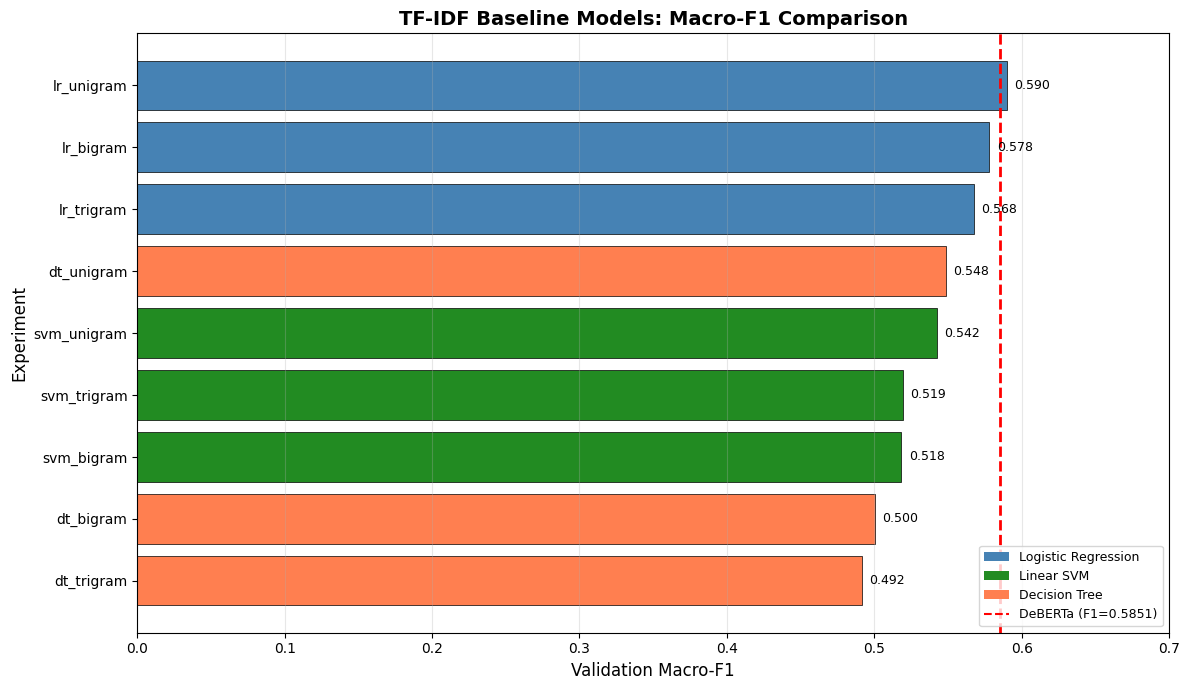


Chart saved to: tfidf_comparison_chart.png


In [ ]:
# ============================================================================
# VISUALIZATION 1: BAR CHART COMPARISON
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data (sort by F1 for better visualization)
sorted_results = results_df.sort_values('val_macro_f1', ascending=True)

# Color mapping by model type
color_map = {
    'Logistic Regression': 'steelblue',
    'Linear SVM': 'forestgreen',
    'Decision Tree': 'coral'
}
bar_colors = [color_map[m] for m in sorted_results['model_type']]

# Plot horizontal bars
bars = ax.barh(
    sorted_results['experiment_id'],
    sorted_results['val_macro_f1'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.5
)

# Add value labels on bars
for bar, val in zip(bars, sorted_results['val_macro_f1']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# Formatting
ax.set_xlabel('Validation Macro-F1', fontsize=12)
ax.set_ylabel('Experiment', fontsize=12)
ax.set_title('TF-IDF Baseline Models: Macro-F1 Comparison', fontsize=14, fontweight='bold')
ax.set_xlim(0, 0.7)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Add legend for model types
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Logistic Regression'),
    Patch(facecolor='forestgreen', label='Linear SVM'),
    Patch(facecolor='coral', label='Decision Tree')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('tfidf_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved to: tfidf_comparison_chart.png")

BEST TF-IDF MODEL
Experiment: lr_unigram
Model Type: Logistic Regression
TF-IDF Config: unigram (1, 1)
Validation Macro-F1: 0.5901
Best Hyperparameters: {'clf__C': 10.0, 'clf__class_weight': 'balanced'}


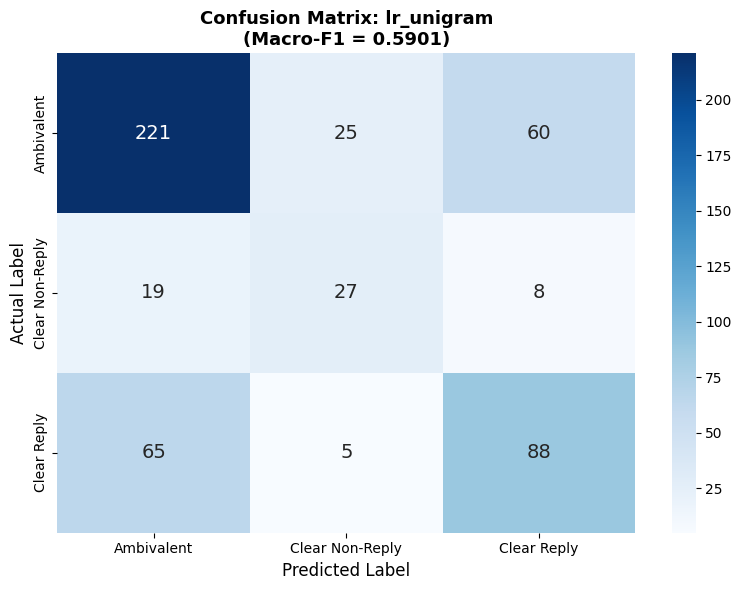


CLASSIFICATION REPORT
                 precision    recall  f1-score   support

     Ambivalent       0.72      0.72      0.72       306
Clear Non-Reply       0.47      0.50      0.49        54
    Clear Reply       0.56      0.56      0.56       158

       accuracy                           0.65       518
      macro avg       0.59      0.59      0.59       518
   weighted avg       0.65      0.65      0.65       518


Confusion matrix saved to: tfidf_best_confusion_matrix.png


In [ ]:
# ============================================================================
# VISUALIZATION 2: CONFUSION MATRIX FOR BEST MODEL
# ============================================================================

# Find the best model
best_idx = results_df['val_macro_f1'].idxmax()
best_result = results_df.loc[best_idx]

print("="*60)
print("BEST TF-IDF MODEL")
print("="*60)
print(f"Experiment: {best_result['experiment_id']}")
print(f"Model Type: {best_result['model_type']}")
print(f"TF-IDF Config: {best_result['tfidf_config']} {best_result['ngram_range']}")
print(f"Validation Macro-F1: {best_result['val_macro_f1']:.4f}")
print(f"Best Hyperparameters: {best_result['best_params']}")

# Get confusion matrix
cm = confusion_matrix(y_val, best_result['y_pred'], labels=LABELS)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax,
            annot_kws={'size': 14})
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title(f"Confusion Matrix: {best_result['experiment_id']}\n(Macro-F1 = {best_result['val_macro_f1']:.4f})",
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('tfidf_best_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print detailed classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_val, best_result['y_pred'], target_names=LABELS))

print("\nConfusion matrix saved to: tfidf_best_confusion_matrix.png")

In [ ]:
# ============================================================================
# ERROR ANALYSIS
# ============================================================================

# Create analysis DataFrame with predictions
error_df = val_df.copy()
error_df['predicted'] = best_result['y_pred']
error_df['correct'] = error_df['clarity_label'] == error_df['predicted']

# Overall error statistics
total_errors = (~error_df['correct']).sum()
print("="*60)
print("ERROR ANALYSIS - BEST TF-IDF MODEL")
print("="*60)
print(f"\nTotal misclassifications: {total_errors} / {len(error_df)} ({100*total_errors/len(error_df):.1f}%)")

# Errors by actual class
print("\n" + "-"*60)
print("Errors by Actual Class:")
print("-"*60)
error_by_class = error_df[~error_df['correct']].groupby('clarity_label').size()
total_by_class = error_df.groupby('clarity_label').size()
error_rate = (error_by_class / total_by_class * 100).round(1)
error_summary = pd.DataFrame({
    'total': total_by_class,
    'errors': error_by_class,
    'error_rate_%': error_rate
})
print(error_summary)

# Most common confusion pairs
print("\n" + "-"*60)
print("Most Common Confusion Pairs (Actual -> Predicted):")
print("-"*60)
confusion_pairs = error_df[~error_df['correct']].groupby(
    ['clarity_label', 'predicted']
).size().sort_values(ascending=False)
print(confusion_pairs)

# Sample misclassified examples
print("\n" + "="*60)
print("SAMPLE MISCLASSIFIED EXAMPLES")
print("="*60)

for actual_label in LABELS:
    errors = error_df[(error_df['clarity_label'] == actual_label) & (~error_df['correct'])]
    if len(errors) > 0:
        sample = errors.sample(min(1, len(errors)), random_state=SEED)
        for _, row in sample.iterrows():
            print(f"\n{'='*60}")
            print(f"Actual: {row['clarity_label']} | Predicted: {row['predicted']}")
            print(f"{'='*60}")
            # Show truncated text
            text = row['text']
            if len(text) > 400:
                text = text[:400] + "..."
            print(f"Text: {text}")

ERROR ANALYSIS - BEST TF-IDF MODEL

Total misclassifications: 182 / 518 (35.1%)

------------------------------------------------------------
Errors by Actual Class:
------------------------------------------------------------
                 total  errors  error_rate_%
clarity_label                               
Ambivalent         306      85          27.8
Clear Non-Reply     54      27          50.0
Clear Reply        158      70          44.3

------------------------------------------------------------
Most Common Confusion Pairs (Actual -> Predicted):
------------------------------------------------------------
clarity_label    predicted      
Clear Reply      Ambivalent         65
Ambivalent       Clear Reply        60
                 Clear Non-Reply    25
Clear Non-Reply  Ambivalent         19
                 Clear Reply         8
Clear Reply      Clear Non-Reply     5
dtype: int64

SAMPLE MISCLASSIFIED EXAMPLES

Actual: Ambivalent | Predicted: Clear Reply
Text: Question: As

In [ ]:
# ============================================================================
# SAVE BEST MODEL
# ============================================================================

# Get the best model pipeline
best_model_pipeline = best_result['best_model']
model_filename = f"best_tfidf_model_{best_result['experiment_id']}.joblib"

# Save using joblib
joblib.dump(best_model_pipeline, model_filename)

print("="*60)
print("MODEL SAVED")
print("="*60)
print(f"\nFilename: {model_filename}")
print(f"\nModel Details:")
print(f"  - Experiment ID: {best_result['experiment_id']}")
print(f"  - Model Type: {best_result['model_type']}")
print(f"  - TF-IDF Config: {best_result['tfidf_config']} {best_result['ngram_range']}")
print(f"  - Best Params: {best_result['best_params']}")
print(f"  - CV Macro-F1: {best_result['cv_macro_f1']:.4f}")
print(f"  - Validation Macro-F1: {best_result['val_macro_f1']:.4f}")

# Verify by loading and testing
print("\n" + "-"*60)
print("Verification - Loading saved model and testing...")
loaded_model = joblib.load(model_filename)
test_preds = loaded_model.predict(X_val[:5])
print(f"Sample predictions: {test_preds}")
print("Model loaded and verified successfully!")

MODEL SAVED

Filename: best_tfidf_model_lr_unigram.joblib

Model Details:
  - Experiment ID: lr_unigram
  - Model Type: Logistic Regression
  - TF-IDF Config: unigram (1, 1)
  - Best Params: {'clf__C': 10.0, 'clf__class_weight': 'balanced'}
  - CV Macro-F1: 0.5008
  - Validation Macro-F1: 0.5901

------------------------------------------------------------
Verification - Loading saved model and testing...
Sample predictions: ['Ambivalent' 'Clear Reply' 'Ambivalent' 'Ambivalent' 'Ambivalent']
Model loaded and verified successfully!


In [ ]:
X_val_text = val_df["text"].astype(str).values
y_val = val_df["label"].values


TF-IDF Best — Standard Evaluation

This cell evaluates the best TF-IDF baseline consistently with other models: it aligns PR scores to LABELS order and saves metrics/confusion/PR curves + the Ambivalent error CSV under artifacts/

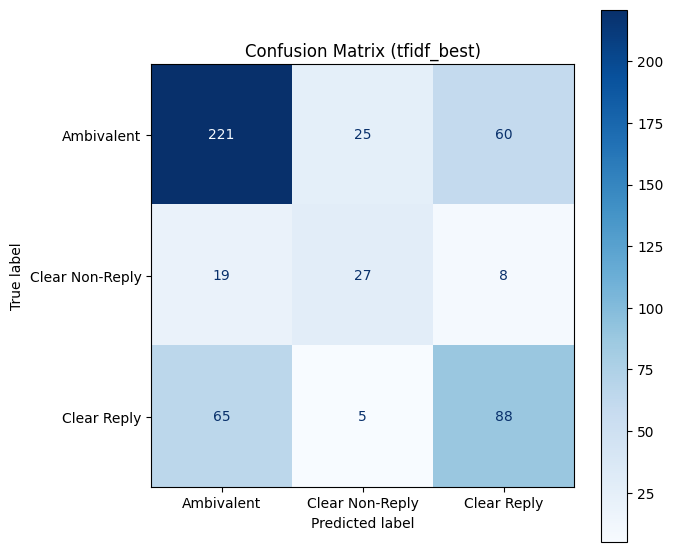

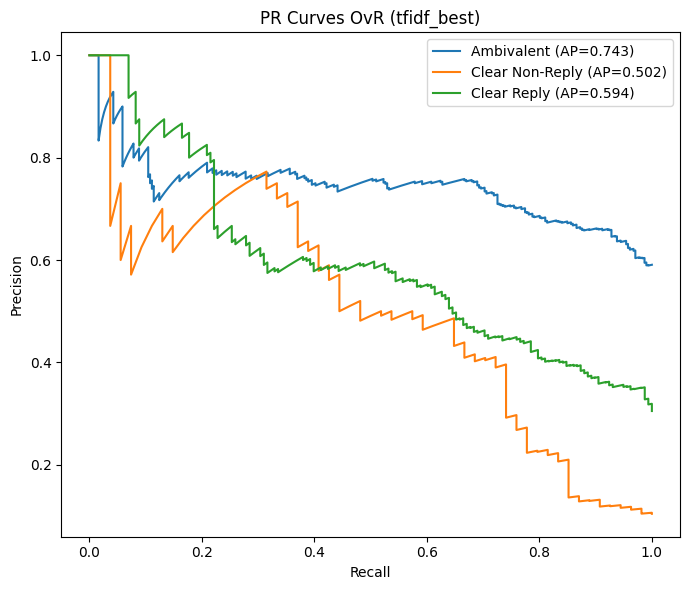

Saved -> artifacts/metrics_tfidf_best.json


In [ ]:
best_model_pipeline = best_result["best_model"]

#scores for PR curves (prefer predict_proba; fallback to decision_function -> softmax)
#getting scores
if hasattr(best_model_pipeline, "predict_proba"):
    scores = best_model_pipeline.predict_proba(X_val_text)
else:
    raw = best_model_pipeline.decision_function(X_val_text)  # (N, C)
    raw = raw - raw.max(axis=1, keepdims=True)
    exp = np.exp(raw)
    scores = exp / exp.sum(axis=1, keepdims=True)

#align score columns to LABELS order
#classes_ could be strings or ints depending on pipeline training
clf = best_model_pipeline.named_steps.get("clf", None)
classes = getattr(clf, "classes_", None)

#building index mapping from pipeline class order -> our LABELS order
# 1st condition pipeline outputs string labels
if classes is not None and isinstance(classes[0], str):
    # LABELS are strings in our notebook (e.g. "Ambivalent Reply")
    idx = [list(classes).index(lbl) for lbl in LABELS]
    tfidf_best_scores = scores[:, idx]
    tfidf_best_pred = best_model_pipeline.predict(X_val_text)
    tfidf_best_pred = np.array([label2id[p] for p in tfidf_best_pred], dtype=int)

#2nd condtion: pipeline outputs numeric labels already (0/1/2)
else:
    #if classes already exist, we reorder columns to [0,1,2] i.e. our LABELS ids
    if classes is not None:
        idx = [list(classes).index(i) for i in range(len(LABELS))]
        tfidf_best_scores = scores[:, idx]
    else:
        tfidf_best_scores = scores

    tfidf_best_pred = best_model_pipeline.predict(X_val_text)
    tfidf_best_pred = np.array(tfidf_best_pred, dtype=int)


m_tfidf_best = run_full_eval(
    tag="tfidf_best",
    y_true=y_val,
    y_pred=tfidf_best_pred,
    y_score=tfidf_best_scores,
    labels=LABELS,
    base_df=val_df
)


In [ ]:
# ============================================================================
# TF-IDF BASELINE SUMMARY
# ============================================================================

print("="*70)
print("TF-IDF BASELINE EXPERIMENTS - FINAL SUMMARY")
print("="*70)

# Best model info
print(f"\n1. BEST MODEL:")
print(f"   - Experiment: {best_result['experiment_id']}")
print(f"   - Validation Macro-F1: {best_result['val_macro_f1']:.4f}")
print(f"   - CV Macro-F1: {best_result['cv_macro_f1']:.4f}")

# N-gram analysis
print(f"\n2. N-GRAM ANALYSIS:")
ngram_perf = results_df.groupby('tfidf_config')['val_macro_f1'].agg(['mean', 'max'])
for config, row in ngram_perf.iterrows():
    print(f"   - {config}: mean={row['mean']:.4f}, max={row['max']:.4f}")

# Model type analysis
print(f"\n3. MODEL TYPE ANALYSIS:")
model_perf = results_df.groupby('model_type')['val_macro_f1'].agg(['mean', 'max'])
for model, row in model_perf.iterrows():
    print(f"   - {model}: mean={row['mean']:.4f}, max={row['max']:.4f}")

# Per-class performance of best model
print(f"\n4. PER-CLASS PERFORMANCE (Best Model):")
print(f"   - Ambivalent F1: {best_result['f1_ambivalent']:.4f}")
print(f"   - Clear Non-Reply F1: {best_result['f1_clear_nonreply']:.4f}")
print(f"   - Clear Reply F1: {best_result['f1_clear_reply']:.4f}")

# Saved artifacts
print(f"\n5. SAVED ARTIFACTS:")
print(f"   - Results CSV: tfidf_baseline_results.csv")
print(f"   - Comparison Chart: tfidf_comparison_chart.png")
print(f"   - Confusion Matrix: tfidf_best_confusion_matrix.png")
print(f"   - Best Model: best_tfidf_model_{best_result['experiment_id']}.joblib")

print("\n" + "="*70)
print("TF-IDF BASELINE IMPLEMENTATION COMPLETE")
print("="*70)

TF-IDF BASELINE EXPERIMENTS - FINAL SUMMARY

1. BEST MODEL:
   - Experiment: lr_unigram
   - Validation Macro-F1: 0.5901
   - CV Macro-F1: 0.5008

2. COMPARISON TO DeBERTa:
   - DeBERTa-v3-small Macro-F1: 0.5851
   - Best TF-IDF Macro-F1: 0.5901
   - Gap: -0.0050 (-0.9% lower)

3. N-GRAM ANALYSIS:
   - bigram: mean=0.5323, max=0.5781
   - trigram: mean=0.5263, max=0.5675
   - unigram: mean=0.5603, max=0.5901

4. MODEL TYPE ANALYSIS:
   - Decision Tree: mean=0.5135, max=0.5484
   - Linear SVM: mean=0.5268, max=0.5424
   - Logistic Regression: mean=0.5786, max=0.5901

5. PER-CLASS PERFORMANCE (Best Model):
   - Ambivalent F1: 0.7234
   - Clear Non-Reply F1: 0.4865
   - Clear Reply F1: 0.5605

6. SAVED ARTIFACTS:
   - Results CSV: tfidf_baseline_results.csv
   - Comparison Chart: tfidf_comparison_chart.png
   - Confusion Matrix: tfidf_best_confusion_matrix.png
   - Best Model: best_tfidf_model_lr_unigram.joblib

TF-IDF BASELINE IMPLEMENTATION COMPLETE


### XGBoost Baseline

XGBoost (TF-IDF) — Data and Features

Uses the existing train/val split and the global LABELS order, builds TF-IDF features, and computes balanced class/sample weights (w_train) for training.

In [ ]:



#text + labels (0..K-1 in the same order as global LABELS)
X_train_text = train_split_df["text"].astype(str).values
X_val_text   = val_df["text"].astype(str).values
y_train      = train_split_df["label"].values
y_val        = val_df["label"].values

num_classes = len(LABELS)
print("Global LABELS order:", LABELS)
print("Train size:", len(X_train_text), "Val size:", len(X_val_text))

#TF-IDF vectorization
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2,
    sublinear_tf=True,
    lowercase=True
)
X_train_vec = tfidf.fit_transform(X_train_text)
X_val_vec   = tfidf.transform(X_val_text)

print("TF-IDF shapes:", X_train_vec.shape, X_val_vec.shape)

#blanced class weights -> sample weights for training
cw = compute_class_weight(class_weight="balanced", classes=np.arange(num_classes), y=y_train)
cw_map = {i: w for i, w in enumerate(cw)}
train_w = np.array([cw_map[i] for i in y_train], dtype=float)

print("Class weights:", {LABELS[i]: round(float(cw_map[i]), 3) for i in range(num_classes)})


Global LABELS order: ['Ambivalent', 'Clear Non-Reply', 'Clear Reply']
Train size: 2930 Val size: 518
TF-IDF shapes: (2930, 50000) (518, 50000)
Class weights: {'Ambivalent': 0.563, 'Clear Non-Reply': 3.234, 'Clear Reply': 1.092}


Train and Evaluate XGBoost (TF-IDF)

Trains an XGBoost multiclass model on TF-IDF features (using balanced sample_weight), predicts validation probabilities, reports accuracy/macro-F1, and runs the unified run_full_eval to save metrics, confusion matrix, PR curves, and error CSVs under artifacts/.


================ XGBoost Results (Validation) ================
Accuracy: 0.6525
Macro-F1: 0.601
Weighted-F1: 0.6483

Classification Report:
                 precision    recall  f1-score   support

     Ambivalent       0.70      0.75      0.73       306
Clear Non-Reply       0.56      0.54      0.55        54
    Clear Reply       0.57      0.49      0.53       158

       accuracy                           0.65       518
      macro avg       0.61      0.60      0.60       518
   weighted avg       0.65      0.65      0.65       518



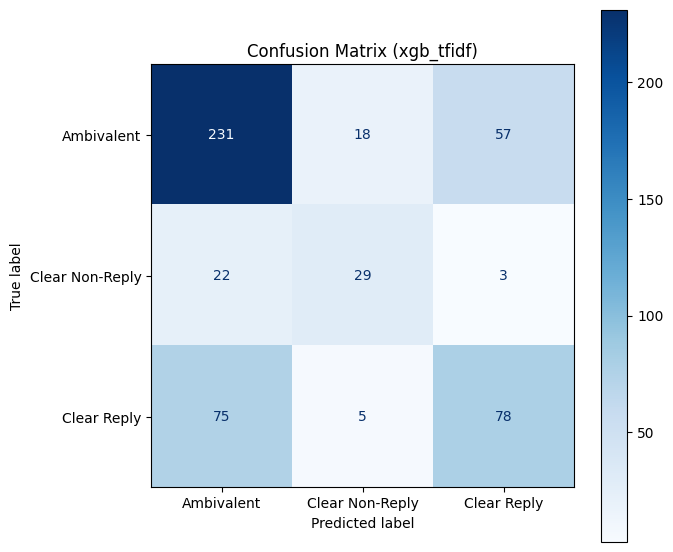

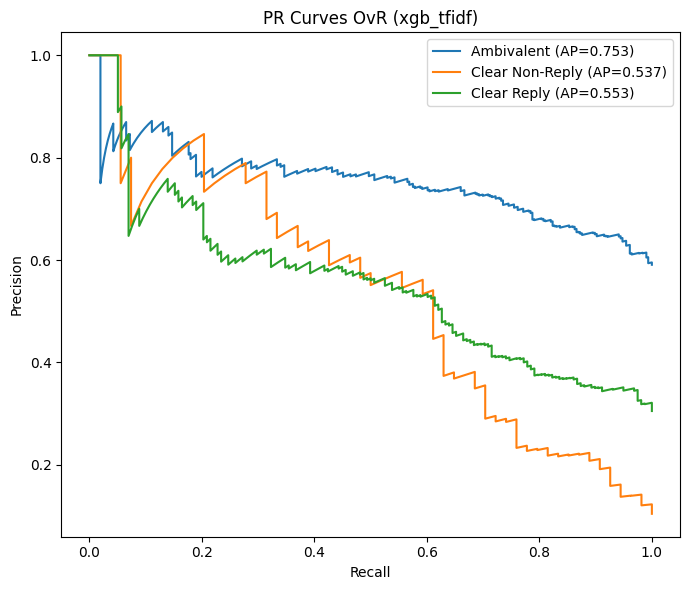

Saved -> artifacts/metrics_xgb_tfidf.json


In [ ]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=SEED,
    eval_metric="mlogloss",
    tree_method="hist"
)

xgb.fit(
    X_train_vec, y_train,
    sample_weight=train_w,
    eval_set=[(X_val_vec, y_val)],
    verbose=False
)

val_probs = xgb.predict_proba(X_val_vec)
val_pred  = np.argmax(val_probs, axis=1)

acc = accuracy_score(y_val, val_pred)
macro_f1 = f1_score(y_val, val_pred, average="macro")
weighted_f1 = f1_score(y_val, val_pred, average="weighted")

print("\n================ XGBoost Results (Validation) ================")
print("Accuracy:", round(acc, 4))
print("Macro-F1:", round(macro_f1, 4))
print("Weighted-F1:", round(weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(y_val, val_pred, target_names=LABELS, digits=2))


#unified evaluation artifacts (macro P/R/F1 + confusion + PR + Ambivalent CSV)
m_xgb_tfidf = run_full_eval(
    tag="xgb_tfidf",
    y_true=y_val,
    y_pred=val_pred,
    y_score=val_probs,
    labels=LABELS,
    base_df=val_df
)


FastText + XGBoost (Mean Embeddings)

Trains unsupervised FastText embeddings on the combined corpus, represents each text as the mean of its word vectors, then fits a multiclass XGBoost model with balanced sample_weight. Reports validation metrics, plots confusion matrix + PR curves, and saves unified artifacts via run_full_eval under artifacts/.

Labels (global order): ['Ambivalent', 'Clear Non-Reply', 'Clear Reply']
Train size: 2930 Val size: 518
Embedding dim: 200
Class weights: {'Ambivalent': np.float64(0.563), 'Clear Non-Reply': np.float64(3.234), 'Clear Reply': np.float64(1.092)}

================= FastText+XGBoost Results (Validation) =================
Accuracy: 0.6506
Macro-F1: 0.5748
Weighted-F1: 0.6359

Classification Report:
                 precision    recall  f1-score   support

     Ambivalent       0.68      0.81      0.74       306
Clear Non-Reply       0.60      0.44      0.51        54
    Clear Reply       0.56      0.41      0.47       158

       accuracy                           0.65       518
      macro avg       0.62      0.55      0.57       518
   weighted avg       0.64      0.65      0.64       518



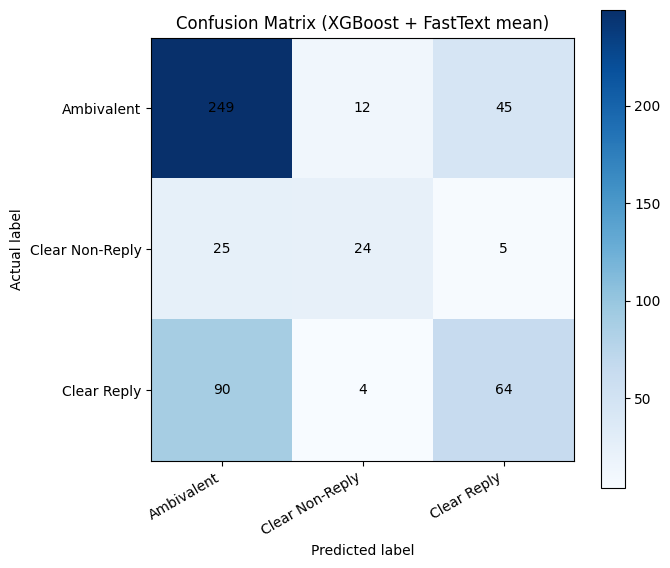

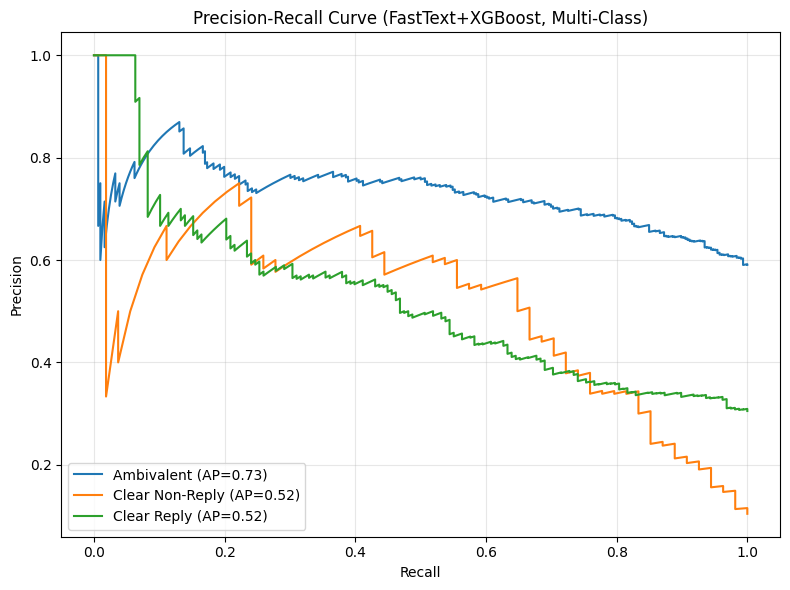

AP per class: {'Ambivalent': 0.73, 'Clear Non-Reply': 0.516, 'Clear Reply': 0.523}
Saved -> artifacts/metrics_fasttext_xgb.json


In [ ]:
# Install FastText
!pip -q install fasttext-wheel

import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import fasttext

# Tokenizer for Embeddings
def simple_tok(s: str):
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s.split()

# Build Corpus File
corpus_path = "qevasion_corpus.txt"
with open(corpus_path, "w", encoding="utf-8") as f:
    for t in pd.concat([train_split_df["text"], val_df["text"]]).astype(str).tolist():
        f.write(t.replace("\n", " ") + "\n")

# Train FastText Unsupervised
ft = fasttext.train_unsupervised(
    corpus_path,
    model="skipgram",
    dim=200,
    ws=5,
    minn=3,
    maxn=6,
    epoch=10,
    lr=0.05,
    thread=4
)

DIM = ft.get_dimension()

# Sentence Embedding (Mean of Word Vectors)
def sent_vec(text: str):
    toks = simple_tok(text)
    if not toks:
        return np.zeros(DIM, dtype=np.float32)
    vecs = [ft.get_word_vector(w) for w in toks]
    return np.mean(vecs, axis=0).astype(np.float32)

X_train = np.vstack([sent_vec(t) for t in train_split_df["text"].astype(str).tolist()])
X_val   = np.vstack([sent_vec(t) for t in val_df["text"].astype(str).tolist()])

# Prepare Labels
y_train = train_split_df["label"].values
y_val   = val_df["label"].values

num_classes = len(LABELS)

print("Labels (global order):", list(LABELS))
print("Train size:", X_train.shape[0], "Val size:", X_val.shape[0])
print("Embedding dim:", DIM)

# Compute Sample Weights
cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
cw_map = {c: w for c, w in zip(np.unique(y_train), cw)}
w_train = np.array([cw_map[c] for c in y_train], dtype=float)
print("Class weights:", {LABELS[k]: round(v, 3) for k, v in cw_map.items()})

# Train XGBoost
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=SEED,
    eval_metric="mlogloss",
    tree_method="hist"
)

xgb.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Evaluate
val_probs = xgb.predict_proba(X_val)
val_pred  = np.argmax(val_probs, axis=1)

acc = accuracy_score(y_val, val_pred)
macro_f1 = f1_score(y_val, val_pred, average="macro")
weighted_f1 = f1_score(y_val, val_pred, average="weighted")

print("\n================= FastText+XGBoost Results (Validation) =================\n")
print("Accuracy:", round(acc, 4))
print("Macro-F1:", round(macro_f1, 4))
print("Weighted-F1:", round(weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(y_val, val_pred, target_names=LABELS, digits=2))

# Evaluation Artifacts
m_fasttext_xgb = run_full_eval(
    tag="fasttext_xgb",
    y_true=y_val,
    y_pred=val_pred,
    y_score=val_probs,
    labels=LABELS,
    base_df=val_df,
    make_plots=False
)

###Transformer Models — Fine-tuning & Evaluation (DeBERTa)

DeBERTa-v3-small

Fine-tunes microsoft/deberta-v3-small on the train/val split using a custom WeightedTrainer (class-weighted cross-entropy). Reports macro P/R/F1 each epoch, then computes validation probabilities and runs run_full_eval to save metrics, confusion matrix, PR curves, and error CSVs under artifacts/

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


...

Starting Training...


model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall
1,1.092900,1.018967,0.357412,0.297440,0.462963
2,0.913800,0.837033,0.457795,0.468077,0.580564
3,0.720900,0.827160,0.455412,0.495726,0.599312
4,0.649300,0.813984,0.581974,0.561414,0.614448



Evaluating on Validation Set...


Validation Macro F1: 0.5820

Classification Report:
                 precision    recall  f1-score   support

     Ambivalent       0.69      0.63      0.66       306
Clear Non-Reply       0.52      0.72      0.60        54
    Clear Reply       0.48      0.49      0.49       158

       accuracy                           0.60       518
      macro avg       0.56      0.61      0.58       518
   weighted avg       0.61      0.60      0.60       518



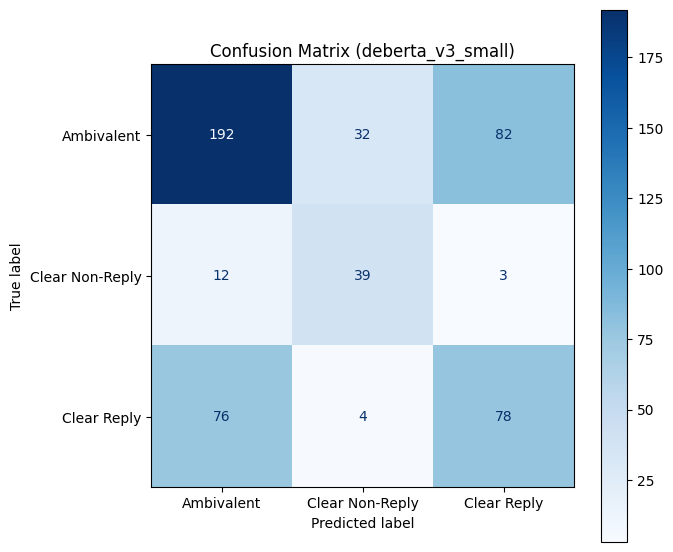

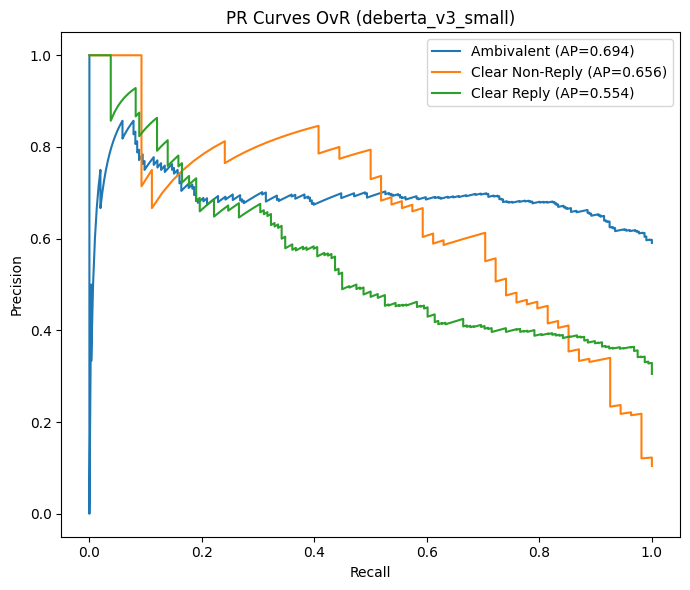

Saved -> artifacts/metrics_deberta_v3_small.json


In [ ]:
import torch
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

# Configuration
MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LEN = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset Conversion
train_ds = Dataset.from_pandas(train_split_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])
test_ds = Dataset.from_pandas(test_df[["text", "label"]])

# Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

encoded_train = train_ds.map(tokenize_function, batched=True)
encoded_val   = val_ds.map(tokenize_function, batched=True)
encoded_test  = test_ds.map(tokenize_function, batched=True)

# Prepare Columns for Trainer
encoded_train = encoded_train.rename_column("label", "labels")
encoded_val   = encoded_val.rename_column("label", "labels")

cols_to_remove = ["text"]
encoded_train = encoded_train.remove_columns(cols_to_remove)
encoded_val   = encoded_val.remove_columns(cols_to_remove)

# Custom Trainer with Class Weights
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# Evaluation Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro"),
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
    }

# Model Initialization
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
).to(device)

# Training Setup
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    save_total_limit=2,
    logging_steps=50,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_train,
    eval_dataset=encoded_val,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

# Train and Evaluate
print("Starting Training...")
trainer.train()

print("\nEvaluating on Validation Set...")
val_results = trainer.evaluate()
print(f"Validation Macro F1: {val_results['eval_macro_f1']:.4f}")

# Classification Report
preds_output = trainer.predict(encoded_val)
pred_labels = np.argmax(preds_output.predictions, axis=1)
true_labels = preds_output.label_ids

print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=LABELS))

import torch.nn.functional as F
val_probs_small = F.softmax(torch.tensor(preds_output.predictions), dim=1).cpu().numpy()
m_deberta_v3_small = run_full_eval(
    tag="deberta_v3_small",
    y_true=true_labels,
    y_pred=pred_labels,
    y_score=val_probs_small,
    labels=LABELS,
    base_df=val_df
)

DeBERTa-v3-base

Fine-tunes microsoft/deberta-v3-base with class-weighted cross-entropy (to handle imbalance) using GPU-friendly settings (fp16 + gradient accumulation). Tracks macro P/R/F1 on the validation set, then runs run_full_eval to save metrics, confusion matrix, PR curves, and error analysis files under artifacts/.

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


...

Starting Training (approx 15-20 mins)...


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall
1,1.056400,1.035071,0.471948,0.686138,0.477317
2,0.847000,0.837559,0.533207,0.543091,0.607007
3,0.737900,0.775728,0.596099,0.578934,0.657364
4,0.610800,0.836422,0.638212,0.646713,0.679284
5,0.538800,0.714212,0.658814,0.648497,0.718550
6,0.426300,0.780345,0.702102,0.680777,0.732982
7,0.369100,0.887775,0.673066,0.668165,0.701828
8,0.232600,0.913795,0.690399,0.686332,0.717893
9,0.170500,1.071256,0.691404,0.697063,0.690967
10,0.135600,1.046991,0.689813,0.682542,0.706962



Evaluating on Validation Set...


VAL metrics: {'eval_loss': 0.7803, 'eval_macro_f1': 0.7021, 'eval_macro_precision': 0.6808, 'eval_macro_recall': 0.733, 'eval_runtime': 1.3755, 'eval_samples_per_second': 376.587, 'eval_steps_per_second': 23.991}

Generating validation predictions...

Classification Report (VAL):
                 precision    recall  f1-score   support

     Ambivalent       0.79      0.74      0.76       306
Clear Non-Reply       0.62      0.81      0.70        54
    Clear Reply       0.63      0.65      0.64       158

       accuracy                           0.72       518
      macro avg       0.68      0.73      0.70       518
   weighted avg       0.73      0.72      0.72       518



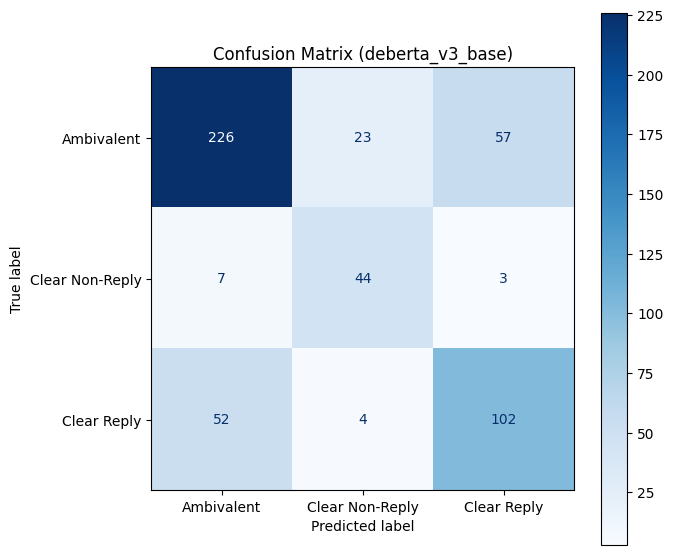

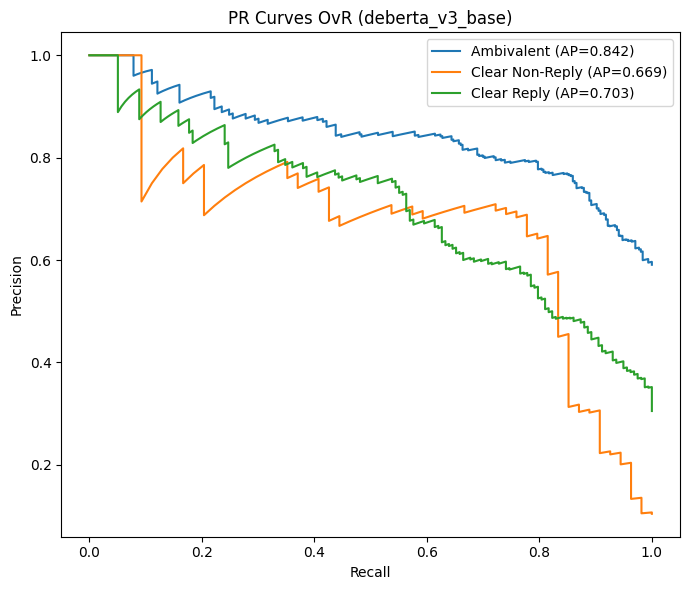

Saved -> artifacts/metrics_deberta_v3_base.json


In [ ]:

# ==============================================================================
# 1. Configuration (Optimized for GPU)
# ==============================================================================
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 300
BATCH_SIZE = 8
GRAD_ACCUM = 4
LEARNING_RATE = 3e-5  # INCREASED: Was 1e-5. This pushes the model harder.
EPOCHS = 10           # INCREASED: Was 5. Gives the model time to finish learning.
# Detect device


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================================================================
# 2. Data Preparation
# ==============================================================================
# Convert pandas DataFrames to Hugging Face Datasets
train_ds = Dataset.from_pandas(train_split_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])

# Initialize Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

print("Tokenizing data...")
encoded_train = train_ds.map(tokenize_function, batched=True)
encoded_val   = val_ds.map(tokenize_function, batched=True)

# Formatting for PyTorch
encoded_train = encoded_train.rename_column("label", "labels")
encoded_val   = encoded_val.rename_column("label", "labels")
cols_to_remove = ["text"]
encoded_train = encoded_train.remove_columns(cols_to_remove)
encoded_val   = encoded_val.remove_columns(cols_to_remove)

# ==============================================================================
# 3. Custom Trainer with Class Weights
# ==============================================================================
# Ensure class_weights is a tensor on the correct device
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Weighted Cross Entropy Loss
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# ==============================================================================
# 4. Model Initialization
# ==============================================================================
# Define Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro"),
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
    }

print(f"Loading {MODEL_NAME}...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
).to(device)

# ==============================================================================
# 5. Training Arguments & Execution
# ==============================================================================
training_args = TrainingArguments(
    output_dir="./results_base",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,

    # --- Performance & Memory Settings ---
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=GRAD_ACCUM,
    fp16=True,  # Mixed precision (Faster + Less Memory)
    # -------------------------------------

    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    save_total_limit=2,
    logging_steps=50,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_train,
    eval_dataset=encoded_val,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

print("Starting Training (approx 15-20 mins)...")
trainer.train()

print("\nEvaluating on Validation Set...")
val_results_base = trainer.evaluate()
print("VAL metrics:", {k: round(v, 4) for k, v in val_results_base.items() if k.startswith("eval_")})

print("\nGenerating validation predictions...")
preds_output_base = trainer.predict(encoded_val)
y_pred_base = np.argmax(preds_output_base.predictions, axis=1)
y_true_base = preds_output_base.label_ids

print("\nClassification Report (VAL):")
print(classification_report(y_true_base, y_pred_base, target_names=LABELS))

# ---- Unified evaluation artifacts ----
import torch.nn.functional as F
val_probs_base = F.softmax(torch.tensor(preds_output_base.predictions), dim=1).cpu().numpy()
m_deberta_v3_base = run_full_eval(
    tag="deberta_v3_base",
    y_true=y_true_base,
    y_pred=y_pred_base,
    y_score=val_probs_base,
    labels=LABELS,
    base_df=val_df
)


In [ ]:
# Submission Generation

# Prepare Test Data (Fresh Tokenization)
raw_test_df = pd.read_parquet("hf://datasets/ailsntua/QEvasion/data/test-00000-of-00001.parquet")

print(f"Tokenizing test set with current settings (MAX_LEN={MAX_LEN})...")
from datasets import Dataset
test_ds_fresh = Dataset.from_pandas(test_df[["text"]])
encoded_test_fresh = test_ds_fresh.map(tokenize_function, batched=True)

# Run Inference
print("Running prediction...")
test_predictions = trainer.predict(encoded_test_fresh)

# Post-processing
y_test_preds = np.argmax(test_predictions.predictions, axis=1)
final_labels = [LABELS[i] for i in y_test_preds]

# Create Submission DataFrame
submission_df = pd.DataFrame({
    "id": raw_test_df["index"],
    "label": final_labels
})

# Export to CSV
output_path = "semeval_task1_submission.csv"
submission_df.to_csv(output_path, index=False)

print(f"\nSuccessfully saved submission file to: {output_path}")
print(f"Shape: {submission_df.shape}")
display(submission_df.head())

KeyError: 'id'

In [ ]:
val_output = preds_output_base


In [ ]:

# 1. Get Probabilities (Softmax) from Logits
# ==============================================================================
# The trainer output gives "logits" (raw numbers). We need probabilities (0 to 1).
# We use the 'val_output' variable from the previous step.
logits_tensor = torch.tensor(val_output.predictions)
probs_tensor = F.softmax(logits_tensor, dim=1)
y_score = probs_tensor.numpy() # Convert back to numpy for sklearn

# 2. Prepare Labels (Binarize)
# ==============================================================================
# Sklearn needs one-hot encoded labels for multi-class PR curves
# e.g., 2 -> [0, 0, 1]
y_test_bin = label_binarize(val_output.label_ids, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# 3. Calculate Precision & Recall for each class
# ==============================================================================
precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])

# 4. Plot the Curves
# ==============================================================================
colors = ['orange', 'green', 'blue'] # Matches your earlier EDA colors roughly
plt.figure(figsize=(10, 7))

for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label='{0} (AP = {1:0.2f})'.format(LABELS[i], average_precision[i]))

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Multi-Class)")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

#Error Analysis and Diagnostics

This section compares all models and drills down into error patterns—especially Ambivalent—using confusion pairs, per-class error rates, and curated example CSVs saved under artifacts/

Model Comparison (Macro Metrics + Ambivalent Errors)

Aggregating the saved evaluation outputs in `artifacts/metrics_*.json` and produces a single comparison table.


In [ ]:


ART = Path('artifacts')
metrics_files = sorted(ART.glob('metrics_*.json'))

if not metrics_files:
    raise FileNotFoundError('No metrics_*.json files found under artifacts/. Run at least one model evaluation cell first.')

rows = []
for fp in metrics_files:
    with open(fp, 'r', encoding='utf-8') as f:
        m = json.load(f)
    tag = m.get('tag') or fp.stem.replace('metrics_', '')
    amb = m.get('ambivalent_summary', {}) or {}
    rows.append({
        'model': tag,
        'macro_f1': m.get('macro_f1'),
        'macro_precision': m.get('macro_precision'),
        'macro_recall': m.get('macro_recall'),
        'amb_label': amb.get('amb_label'),
        'amb_true_count': amb.get('true_amb_count'),
        'amb_error_count': amb.get('amb_error_count'),
    })

df_cmp = pd.DataFrame(rows)
df_cmp = df_cmp.sort_values(['macro_f1', 'macro_precision', 'macro_recall'], ascending=False).reset_index(drop=True)

out_csv = ART / 'model_comparison.csv'
df_cmp.to_csv(out_csv, index=False)
print('Saved ->', out_csv)
df_cmp


FileNotFoundError: No metrics_*.json files found under artifacts/. Run at least one model evaluation cell first.

1. Ambivalent Error Rate Comparison

    Computes each model’s Ambivalent error rate (amb_error_count / amb_true_count) and displays a compact comparison table (df_cmp) alongside macro-F1/precision/recall.

In [ ]:
df_cmp["amb_error_rate"] = df_cmp["amb_error_count"] / df_cmp["amb_true_count"]
df_cmp


,model,macro_f1,macro_precision,macro_recall,amb_label,amb_true_count,amb_error_count,amb_error_rate
0,deberta_v3_base,0.712325,0.692508,0.742547,Ambivalent,306,87,0.284314
1,xgb_tfidf,0.600968,0.609059,0.595203,Ambivalent,306,75,0.245098
2,tfidf_best,0.590133,0.587459,0.593061,Ambivalent,306,85,0.277778
3,deberta_v3_small,0.587907,0.569343,0.618235,Ambivalent,306,105,0.343137
4,fasttext_xgb,0.574837,0.615156,0.554411,Ambivalent,306,57,0.186275


2. Top Confusion Pairs (Actual → Pred)

    Summarizes each model’s misclassifications and lists the top-5 most frequent confusion pairs (true label → predicted label) to highlight where models most often fail.

In [ ]:


ART = Path("artifacts")

#reading mode comparison table we created
cmp_path = ART / "model_comparison.csv"
df_cmp = pd.read_csv(cmp_path)

# adding mbivalent error rate
df_cmp["amb_error_rate"] = df_cmp["amb_error_count"] / df_cmp["amb_true_count"]

print("\n\n TOP CONFUSION PAIRS PER MODEL (Actual -> Pred) \n")

for tag in df_cmp["model"].tolist():
    err_path = ART / f"errors_full_{tag}.csv"
    if not err_path.exists():
        print(f"[{tag}] missing: {err_path.name}")
        continue

    err_df = pd.read_csv(err_path)
    mis = err_df[err_df["is_error"] == True].copy()

    # Count confusion pairs
    pairs = (mis.groupby(["true_label","pred_label"])
                .size()
                .sort_values(ascending=False)
                .head(5))

    total_err = int(mis.shape[0])
    total = int(err_df.shape[0])
    print(f"\n--- {tag} ---")
    print(f"Total misclassifications: {total_err} / {total} ({100*total_err/total:.1f}%)")
    print("Most common confusion pairs (top-5):")
    print(pairs.to_string())




 TOP CONFUSION PAIRS PER MODEL (Actual -> Pred) 


--- deberta_v3_base ---
Total misclassifications: 141 / 518 (27.2%)
Most common confusion pairs (top-5):
true_label       pred_label     
Ambivalent       Clear Reply        65
Clear Reply      Ambivalent         39
Ambivalent       Clear Non-Reply    22
Clear Non-Reply  Ambivalent          9
                 Clear Reply         3

--- xgb_tfidf ---
Total misclassifications: 180 / 518 (34.7%)
Most common confusion pairs (top-5):
true_label       pred_label     
Clear Reply      Ambivalent         75
Ambivalent       Clear Reply        57
Clear Non-Reply  Ambivalent         22
Ambivalent       Clear Non-Reply    18
Clear Reply      Clear Non-Reply     5

--- tfidf_best ---
Total misclassifications: 182 / 518 (35.1%)
Most common confusion pairs (top-5):
true_label       pred_label     
Clear Reply      Ambivalent         65
Ambivalent       Clear Reply        60
                 Clear Non-Reply    25
Clear Non-Reply  Ambivalent        

3) Error Rate by True Class (per Model)

    Reads errors_full_*.csv files under artifacts/, computes per-class error rates (errors / total) for each model, and prints a model × true-class table for quick comparison.

In [ ]:

ART = Path("artifacts")

print("\n ERROR RATE BY TRUE CLASS (PER MODEL):\n")

rows = []
for fp in sorted(ART.glob("errors_full_*.csv")):
    tag = fp.stem.replace("errors_full_", "")
    df = pd.read_csv(fp)
    # true class totals
    totals = df["true_label"].value_counts()
    errors = df[df["is_error"] == True]["true_label"].value_counts()

    for lbl in totals.index:
        tot = int(totals[lbl])
        err = int(errors.get(lbl, 0))
        rows.append({
            "model": tag,
            "true_class": lbl,
            "total": tot,
            "errors": err,
            "error_rate": err / tot if tot else np.nan
        })

df_err_by_class = pd.DataFrame(rows)

# model x class pivot
pivot = df_err_by_class.pivot_table(index="model", columns="true_class", values="error_rate")
pivot = pivot.loc[sorted(pivot.index)]  # stabil

print(pivot.to_string(float_format=lambda x: f"{100*x:5.1f}%"))



 ERROR RATE BY TRUE CLASS (PER MODEL):

true_class        Ambivalent  Clear Non-Reply  Clear Reply
model                                                     
deberta_v3_base        28.4%            22.2%        26.6%
deberta_v3_small       34.3%            31.5%        48.7%
fasttext_xgb           18.6%            55.6%        59.5%
tfidf_best             27.8%            50.0%        44.3%
xgb_tfidf              24.5%            46.3%        50.6%


4. Sample Ambivalent Errors (Best Model)

    Selects the best model by macro_f1, loads its ambivalent_examples_{model}.csv from artifacts/, and displays a few low-confidence Ambivalent misclassifications for quick qualitative inspection.

In [ ]:
best_model = df_cmp.sort_values("macro_f1", ascending=False).iloc[0]["model"]
amb_path = ART / f"ambivalent_examples_{best_model}.csv"

print("\n SAMPLE AMBIVALENT ERRORS (BEST MODEL): \n")
print("Best model:", best_model)
if amb_path.exists():
    ex = pd.read_csv(amb_path)
    display(ex.head(10))
else:
    print("Missing:", amb_path.name)



 SAMPLE AMBIVALENT ERRORS (BEST MODEL): 

Best model: deberta_v3_base


,bucket,true_label,pred_label,confidence,question,interview_answer,text,multiple_questions,affirmative_questions,inaudible
0,low_conf,Ambivalent,Clear Non-Reply,0.490128,And is there any truth to allegations that Is...,"Let me, first of all, address your second ques...",Question: And is there any truth to allegation...,True,False,False
1,low_conf,Ambivalent,Clear Reply,0.492847,"Can you tell the country, sir, why you are con...","I've got to give you credit, Major, for how yo...","Question: Can you tell the country, sir, why y...",False,False,False
2,low_conf,Ambivalent,Clear Reply,0.496178,Are you worried that if you don't manage to pa...,What I'm worried about is how un-American this...,Question: Are you worried that if you don't ma...,False,False,False
3,low_conf,Ambivalent,Clear Reply,0.496693,Where is this all headed?,"As you know, we have been discussing this issu...",Question: Where is this all headed?\nAnswer: A...,False,False,False
4,low_conf,Ambivalent,Clear Reply,0.503966,Why are you still convinced that a civilian tr...,"Well, we have succeeded on delivering a lot of...",Question: Why are you still convinced that a c...,False,False,False
5,low_conf,Ambivalent,Clear Reply,0.503981,What actions will you take regarding North Ko...,"Let me say that, number one, U.N. Resolution 1...",Question: What actions will you take regarding...,False,False,False
6,low_conf,Ambivalent,Clear Reply,0.504516,Did you carry a special message to the Preside...,"Sir, I would be very happy if it was Poland wh...",Question: Did you carry a special message to t...,False,False,False
7,low_conf,Ambivalent,Clear Reply,0.509070,At what point does it take more active interv...,"Well, first, you know, I've been very active, ...",Question: At what point does it take more acti...,False,False,False
8,low_conf,Ambivalent,Clear Reply,0.512086,How do you think LGBT rights will rank in term...,I could not be prouder of the transformation t...,Question: How do you think LGBT rights will ra...,False,False,False
9,low_conf,Ambivalent,Clear Reply,0.512086,How do you think LGBT rights will rank in term...,I could not be prouder of the transformation t...,Question: How do you think LGBT rights will ra...,False,False,False


5. Ambivalent Error Breakdown (Best Model)

    Loads the best model’s errors_full_{model}.csv, filters true Ambivalent cases, reports the Ambivalent error rate, and shows how they’re misclassified (e.g., as Clear Reply vs Clear Non-Reply).

In [ ]:

ART = Path("artifacts")
best = df_cmp.sort_values("macro_f1", ascending=False).iloc[0]["model"]
df = pd.read_csv(ART / f"errors_full_{best}.csv")

amb = df[df["true_label"]=="Ambivalent"]
amb_err = amb[amb["is_error"]==True]

print("Best model:", best)
print("Ambivalent total:", len(amb), "Ambivalent errors:", len(amb_err), f"({100*len(amb_err)/len(amb):.1f}%)")
print("\nAmbivalent misclassified as:")
print(amb_err["pred_label"].value_counts().to_string())


Best model: deberta_v3_base
Ambivalent total: 306 Ambivalent errors: 87 (28.4%)

Ambivalent misclassified as:
pred_label
Clear Reply        65
Clear Non-Reply    22


6. Ambivalent Error Analysis (Best Model)

    Analyzes the sampled Ambivalent mistakes for the best model: bucket distribution (low/high confidence), most common confusions, confidence statistics, and flag rates (multiple/affirmative/inaudible), then prints a short summary of key patterns.

In [ ]:

# ex = pd.read_csv(amb_path)

print("\n AMBIVALENT ERROR ANALYSIS (BEST MODEL) \n")

n = len(ex)
print(f"Total sampled Ambivalent errors in CSV: {n} (this file contains low_conf + high_conf examples)")

#bucket distribution
if "bucket" in ex.columns:
    print("\nBucket distribution:")
    print(ex["bucket"].value_counts(dropna=False).to_string())

# ambivalent -> misclassified as which class?
if "pred_label" in ex.columns:
    print("\nMost common predictions when TRUE=Ambivalent (in this sample):")
    print(ex["pred_label"].value_counts().to_string())

#confidence statistics
if "confidence" in ex.columns:
    def _conf_stats(df, name):
        if len(df) == 0:
            return
        c = df["confidence"].astype(float)
        print(f"\nConfidence stats ({name}):")
        print(f"  n={len(df)} | mean={c.mean():.3f} | median={c.median():.3f} | min={c.min():.3f} | max={c.max():.3f}")

    _conf_stats(ex, "ALL")
    if "bucket" in ex.columns:
        _conf_stats(ex[ex["bucket"]=="low_conf"], "low_conf")
        _conf_stats(ex[ex["bucket"]=="high_conf"], "high_conf")

# 5) most common confusion pair (Ambivalent -> Pred)
if all(c in ex.columns for c in ["true_label","pred_label"]):
    print("\nTop confusion pairs in sample (true -> pred):")
    print(ex.groupby(["true_label","pred_label"]).size().sort_values(ascending=False).to_string())

# 6)flag effects (if any)
flag_cols = [c for c in ["multiple_questions","affirmative_questions","inaudible"] if c in ex.columns]
if flag_cols:
    print("\nFlag rates overall (in this sample):")
    for col in flag_cols:
        #mixed bool/str possible, make robust:
        vals = ex[col].astype(str).str.lower().map(lambda x: True if x=="true" else (False if x=="false" else np.nan))
        print(f"  {col}: True={np.nanmean(vals.values)*100:.1f}% (n={len(vals)})")

    print("\nFlag rates by bucket:")
    if "bucket" in ex.columns:
        for b in ex["bucket"].dropna().unique():
            sub = ex[ex["bucket"]==b]
            print(f"  [{b}]")
            for col in flag_cols:
                vals = sub[col].astype(str).str.lower().map(lambda x: True if x=="true" else (False if x=="false" else np.nan))
                print(f"    {col}: True={np.nanmean(vals.values)*100:.1f}% (n={len(vals)})")

# 2-3 sentence automatic summary
print("\n SUMMARY \n")
top_pred = ex["pred_label"].value_counts().idxmax() if "pred_label" in ex.columns and len(ex)>0 else "N/A"
low_n = int((ex["bucket"]=="low_conf").sum()) if "bucket" in ex.columns else None
high_n = int((ex["bucket"]=="high_conf").sum()) if "bucket" in ex.columns else None
mean_conf = float(ex["confidence"].astype(float).mean()) if "confidence" in ex.columns and len(ex)>0 else None

lines = []
if top_pred != "N/A":
    lines.append(f"- In the sampled Ambivalent errors, the model most often predicts **{top_pred}**, indicating this is the dominant confusion direction.")
if mean_conf is not None:
    lines.append(f"- The average confidence on these Ambivalent mistakes is **{mean_conf:.2f}**, suggesting many errors are near the decision boundary.")
if low_n is not None and high_n is not None:
    lines.append(f"- The sample includes **{low_n} low-confidence** and **{high_n} high-confidence** Ambivalent mistakes; high-confidence errors are good candidates for deeper qualitative inspection (potential label ambiguity or systematic cues).")

print("\n".join(lines) if lines else "N/A")



 AMBIVALENT ERROR ANALYSIS (BEST MODEL) 

Total sampled Ambivalent errors in CSV: 24 (this file contains low_conf + high_conf examples)

Bucket distribution:
bucket
low_conf     12
high_conf    12

Most common predictions when TRUE=Ambivalent (in this sample):
pred_label
Clear Reply        16
Clear Non-Reply     8

Confidence stats (ALL):
  n=24 | mean=0.734 | median=0.728 | min=0.490 | max=0.991

Confidence stats (low_conf):
  n=12 | mean=0.504 | median=0.504 | min=0.490 | max=0.517

Confidence stats (high_conf):
  n=12 | mean=0.963 | median=0.960 | min=0.938 | max=0.991

Top confusion pairs in sample (true -> pred):
true_label  pred_label     
Ambivalent  Clear Reply        16
            Clear Non-Reply     8

Flag rates overall (in this sample):
  multiple_questions: True=4.2% (n=24)
  affirmative_questions: True=12.5% (n=24)
  inaudible: True=0.0% (n=24)

Flag rates by bucket:
  [low_conf]
    multiple_questions: True=8.3% (n=12)
    affirmative_questions: True=0.0% (n=12)
    in